In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import random

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
class BratsNPZDataset(Dataset):
    def __init__(self, npz_dir, max_patients=None):
        self.cache = {}

        files = sorted([
            os.path.join(npz_dir, f)
            for f in os.listdir(npz_dir)
            if f.endswith(".npz")
        ])

        if max_patients is not None:
            files = files[:max_patients]

        self.slice_index = []

        for f in files:
            data = np.load(f)
            y = data["y"]  # (N, H, W)

            for i in range(len(y)):
                self.slice_index.append((f, i))

        print("Total slices:", len(self.slice_index))

    def __len__(self):
        return len(self.slice_index)

    def __getitem__(self, idx):
        file_path, slice_idx = self.slice_index[idx]

        if file_path not in self.cache:
            self.cache[file_path] = np.load(file_path)

        data = self.cache[file_path]

        X = torch.from_numpy(data["X"][slice_idx]).float()   # (4, H, W)
        y = torch.from_numpy(data["y"][slice_idx]).long()    # (H, W)

        return X, y


In [ ]:
from torch.utils.data import DataLoader

dataset = BratsNPZDataset(
    npz_dir="preprocessed_npz3",
    max_patients=50,
)


train_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

len(dataset)


Total slices: 3150


3150

In [ ]:
model = torch.hub.load(
    "mateuszbuda/brain-segmentation-pytorch",
    "unet",
    in_channels=4,
    out_channels=4,
    init_features=16,
    pretrained=False
).to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)



Using cache found in /home/dell/.cache/torch/hub/mateuszbuda_brain-segmentation-pytorch_master


In [ ]:
# ======================
# Training setup
# ======================
epochs = 5
criterion = torch.nn.CrossEntropyLoss()  # multi-class loss

model.train()

for epoch in range(epochs):
    epoch_loss = 0.0

    for step, (x, y) in enumerate(train_loader):


        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

        if step % 50 == 0:
            print(f"Epoch {epoch+1} | Step {step}/{len(train_loader)}")

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1} Avg Loss: {avg_loss:.4f}")


Epoch 1 | Step 0/788
Epoch 1 | Step 50/788
Epoch 1 | Step 100/788
Epoch 1 | Step 150/788
Epoch 1 | Step 200/788
Epoch 1 | Step 250/788
Epoch 1 | Step 300/788
Epoch 1 | Step 350/788
Epoch 1 | Step 400/788
Epoch 1 | Step 450/788
Epoch 1 | Step 500/788
Epoch 1 | Step 550/788
Epoch 1 | Step 600/788
Epoch 1 | Step 650/788
Epoch 1 | Step 700/788
Epoch 1 | Step 750/788
Epoch 1 Avg Loss: 1.2675
Epoch 2 | Step 0/788
Epoch 2 | Step 50/788
Epoch 2 | Step 100/788
Epoch 2 | Step 150/788
Epoch 2 | Step 200/788
Epoch 2 | Step 250/788
Epoch 2 | Step 300/788
Epoch 2 | Step 350/788
Epoch 2 | Step 400/788
Epoch 2 | Step 450/788
Epoch 2 | Step 500/788
Epoch 2 | Step 550/788
Epoch 2 | Step 600/788
Epoch 2 | Step 650/788
Epoch 2 | Step 700/788
Epoch 2 | Step 750/788
Epoch 2 Avg Loss: 1.0879
Epoch 3 | Step 0/788
Epoch 3 | Step 50/788
Epoch 3 | Step 100/788
Epoch 3 | Step 150/788
Epoch 3 | Step 200/788
Epoch 3 | Step 250/788
Epoch 3 | Step 300/788
Epoch 3 | Step 350/788
Epoch 3 | Step 400/788
Epoch 3 | Step 4

In [ ]:
torch.save(model.state_dict(), "unet_final_multiclass.pt")

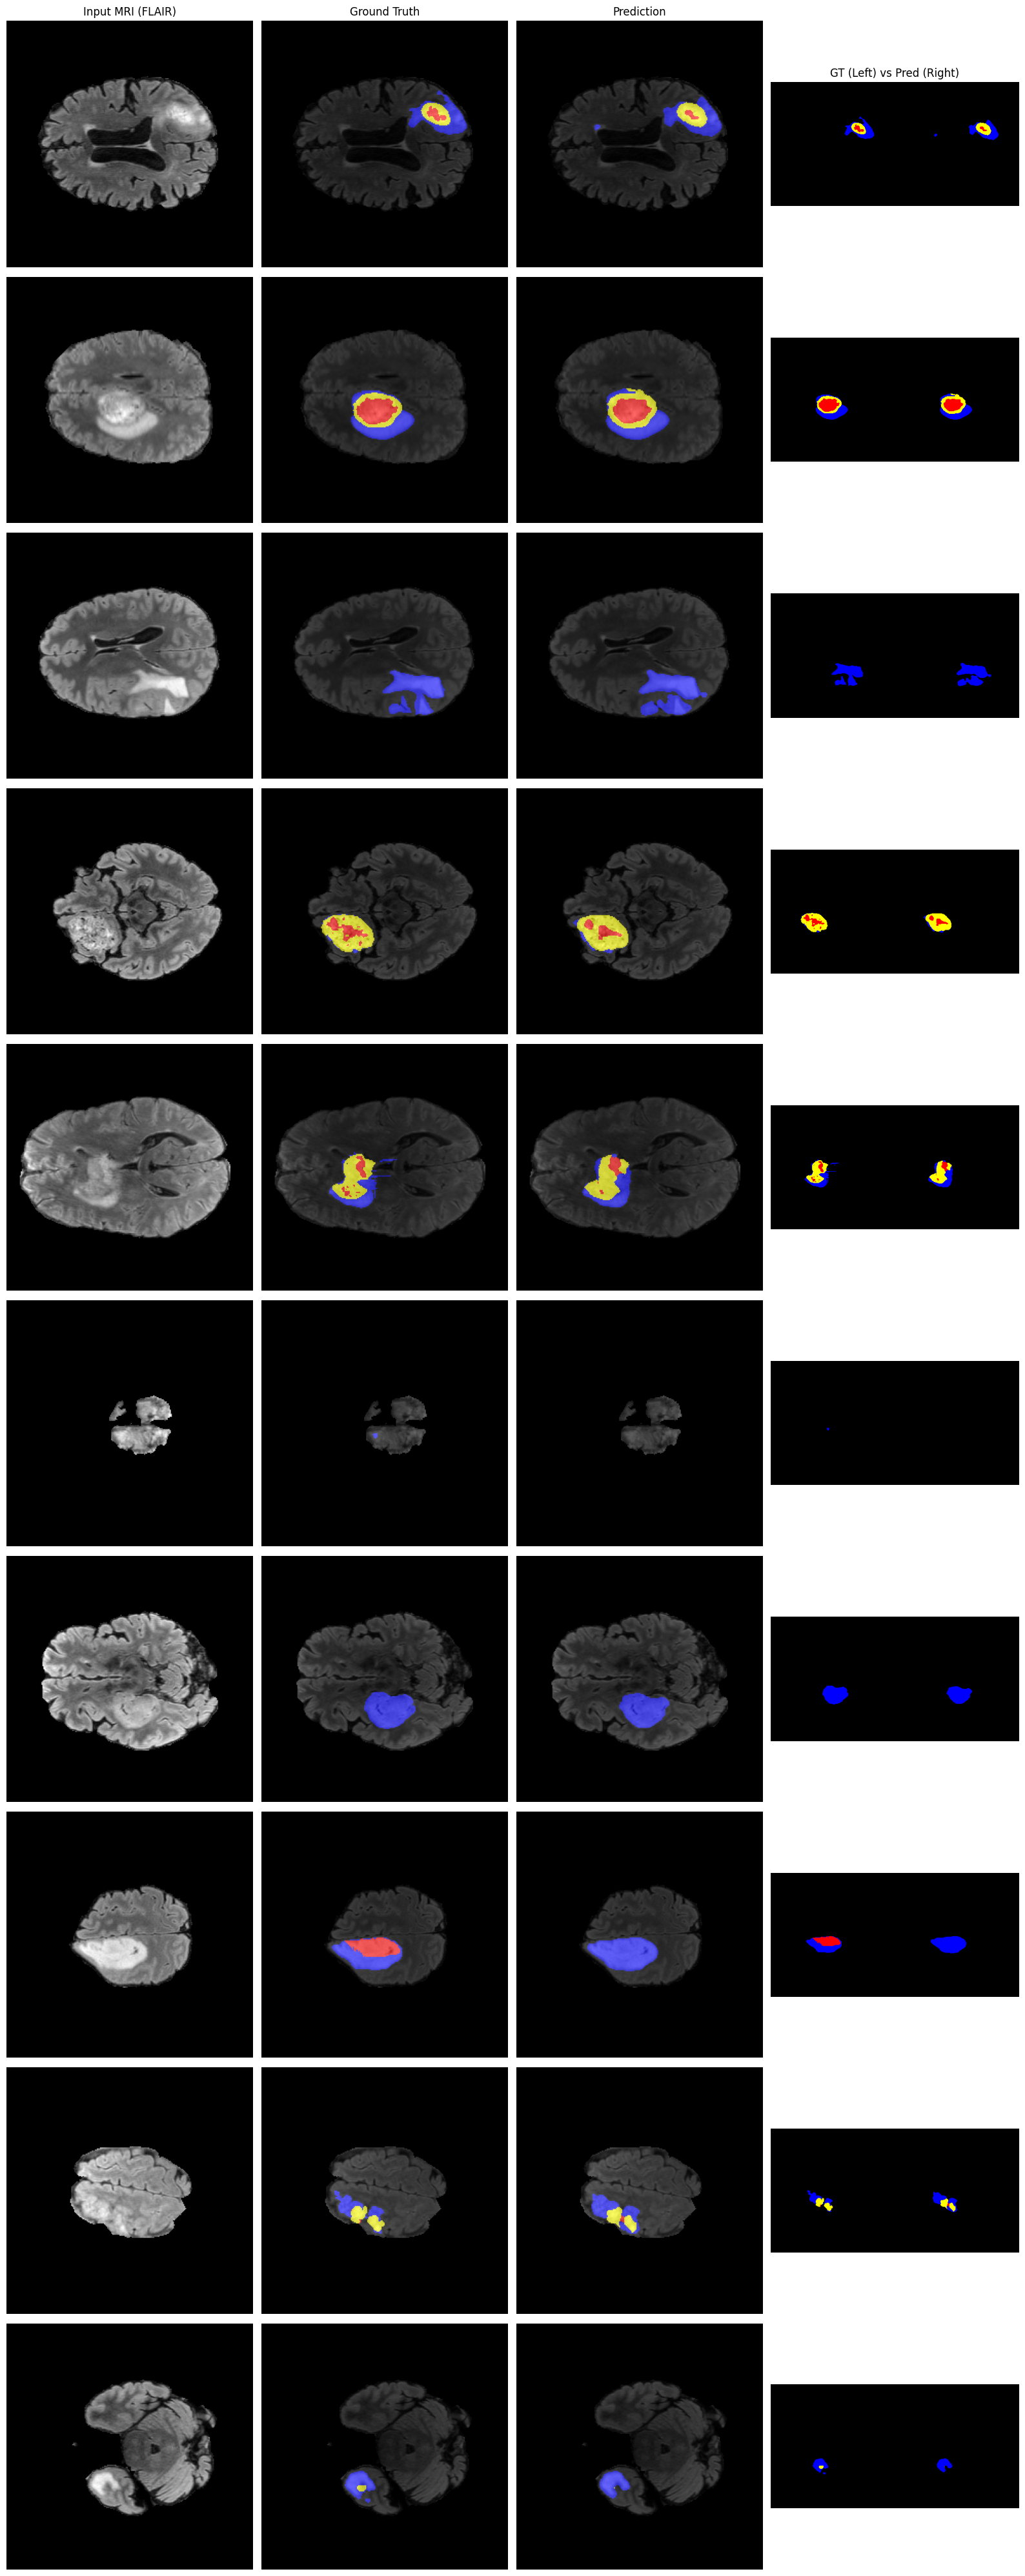

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

viz_loader = DataLoader(
    dataset,
    batch_size=10,
    shuffle=True,
    num_workers=0
)

x, y = next(iter(viz_loader))

with torch.no_grad():
    x, y = next(iter(viz_loader))
    x = x.to(device)
    y = y.to(device)

    logits = model(x)
    preds = torch.argmax(logits, dim=1)  # (B, H, W)

# number of samples to show
num_samples = min(10, x.shape[0])

def color_mask(mask):
    rgb = np.zeros((*mask.shape, 3))

    # class 1 → red
    rgb[mask == 1] = [1, 0, 0]

    # class 2 → blue
    rgb[mask == 2] = [0, 0, 1]

    # class 3 → yellow
    rgb[mask == 3] = [1, 1, 0]

    return rgb

plt.figure(figsize=(16, 4 * num_samples))

for i in range(num_samples):
    flair = x[i, 3].cpu().numpy()
    gt = y[i].cpu().numpy()
    pred = preds[i].cpu().numpy()

    gt_rgb = color_mask(gt)
    pred_rgb = color_mask(pred)

    # -------------------------
    # Input MRI
    # -------------------------
    plt.subplot(num_samples, 4, 4*i + 1)
    plt.imshow(flair, cmap="gray")
    if i == 0:
        plt.title("Input MRI (FLAIR)")
    plt.axis("off")

    # -------------------------
    # Ground Truth
    # -------------------------
    plt.subplot(num_samples, 4, 4*i + 2)
    plt.imshow(flair, cmap="gray")
    plt.imshow(gt_rgb, alpha=0.6)
    if i == 0:
        plt.title("Ground Truth")
    plt.axis("off")

    # -------------------------
    # Prediction
    # -------------------------
    plt.subplot(num_samples, 4, 4*i + 3)
    plt.imshow(flair, cmap="gray")
    plt.imshow(pred_rgb, alpha=0.6)
    if i == 0:
        plt.title("Prediction")
    plt.axis("off")

    # -------------------------
    # GT vs Prediction
    # -------------------------
    plt.subplot(num_samples, 4, 4*i + 4)
    comparison = np.concatenate([gt_rgb, pred_rgb], axis=1)
    plt.imshow(comparison)
    if i == 0:
        plt.title("GT (Left) vs Pred (Right)")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
def dice_score(pred, gt, label):
    pred_bin = (pred == label).float()
    gt_bin = (gt == label).float()

    intersection = (pred_bin * gt_bin).sum()
    union = pred_bin.sum() + gt_bin.sum()

    if union == 0:
        return torch.tensor(1.0, device=pred.device)

    return (2.0 * intersection) / union


In [ ]:
model.eval()

with torch.no_grad():
    x, y = next(iter(viz_loader))
    x = x.to(device)
    y = y.to(device)

    logits = model(x)
    preds = torch.argmax(logits, dim=1)

dice_wt = []
dice_et = []

for i in range(x.shape[0]):
    pred = preds[i]
    gt = y[i]

    # Whole Tumor = labels 1,2,3
    pred_wt = (pred > 0).int()
    gt_wt = (gt > 0).int()

    dice_wt.append(
        (2 * (pred_wt & gt_wt).sum()) /
        (pred_wt.sum() + gt_wt.sum() + 1e-6)
    )

    # Enhancing Tumor = label 3
    dice_et.append(dice_score(pred, gt, label=3))

print("Dice WT:", torch.mean(torch.stack(dice_wt)).item())
print("Dice ET:", torch.mean(torch.stack(dice_et)).item())


Dice WT: 0.8268890380859375
Dice ET: 0.9189020395278931
